In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)
m=100
x1=10*np.random.rand(m,1)-6
y=10+6*x1+5*x1**2+30*np.random.randn(m,1)

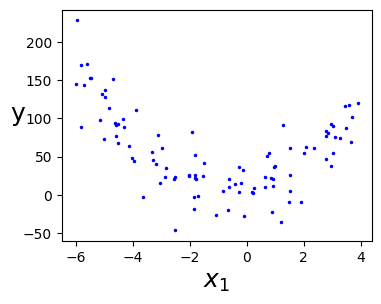

In [3]:
plt.figure(figsize=(4,3))
plt.plot(x1,y,"b.",markersize=3)
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("y",rotation=0,fontsize=18)
plt.savefig("plot_1.pdf",dpi=300,bbox_inches='tight')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
x1_train,x1_test,y_train,y_test=train_test_split(x1,y,test_size=0.2,random_state=1)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

In [9]:
from sklearn.linear_model import Ridge
ridge_reg=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("ridge",Ridge(alpha=m/2,random_state=1))
])
ridge_reg.fit(x1_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('ridge', Ridge(alpha=50.0, random_state=1))])

In [10]:
ridge_reg.score(x1_train,y_train),ridge_reg.score(x1_test,y_test)

(0.5624715988861848, 0.5000997386648434)

In [11]:
ridge_reg.predict(x1_test[:3])

array([50.49773754, 59.13869604, 31.86781274])

In [12]:
from sklearn.linear_model import SGDRegressor
ridge_sgd=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("sgd",SGDRegressor(penalty="l2",alpha=1,random_state=1))
])
ridge_sgd.fit(x1_train,y_train.ravel())

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('sgd', SGDRegressor(alpha=1, random_state=1))])

In [13]:
ridge_sgd.score(x1_train,y_train),ridge_sgd.score(x1_test,y_test)

(0.48914255940966433, 0.4132817374249068)

In [14]:
ridge_sgd.predict(x1_test[:3])

array([47.78375855, 58.58856714, 35.37888686])

In [15]:
def plot_model(model,x1,y):
  x1s=np.linspace(x1.min(),x1.max(),1000).reshape(-1,1)
  y_pred=model.predict(x1s)

  plt.plot(x1_train,y_train,"b.",markersize=3)
  plt.plot(x1_test,y_test,"gx",markersize=3)
  plt.plot(x1s,y_pred,"r-",linewidth=2,label="$\hat y$")

  plt.xlabel("$x_1$",fontsize=18)
  plt.ylabel("y",rotation=0,fontsize=18)
  plt.legend(loc="upper left",fontsize=10)
  plt.legend(loc="upper left",fontsize=10)
  plt.axis([x1.min()-0.1,x1.max()+0.1,y.min()-5,y.max()+5])

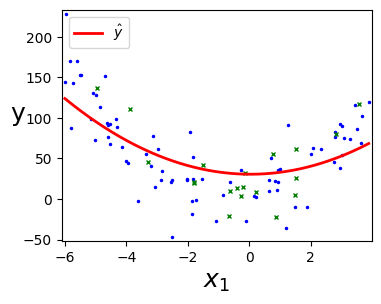

In [16]:
plt.figure(figsize=(4,3))
plot_model(ridge_reg,x1,y)
plt.show()

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

In [18]:
from sklearn.linear_model import Lasso
lasso_reg=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("lasso",Lasso(alpha=1,random_state=1))
])
lasso_reg.fit(x1_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('lasso', Lasso(alpha=1, random_state=1))])

In [19]:
lasso_reg.score(x1_train,y_train),lasso_reg.score(x1_test,y_test)

(0.7289049773635354, 0.7090703555227443)

In [20]:
lasso_reg.predict(x1_test[:3])

array([63.93127861, 47.72171974,  7.57641004])

In [21]:
from sklearn.linear_model import SGDRegressor
lasso_sgd=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("sgd",SGDRegressor(penalty="l1",alpha=1,random_state=1))
])
lasso_sgd.fit(x1_train,y_train.ravel())

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('sgd', SGDRegressor(alpha=1, penalty='l1', random_state=1))])

In [22]:
lasso_sgd.score(x1_train,y_train),lasso_sgd.score(x1_test,y_test)

(0.7284890196449929, 0.7089179245883365)

In [23]:
lasso_sgd.predict(x1_test[:3])

array([63.65542504, 47.90341769,  7.82005821])

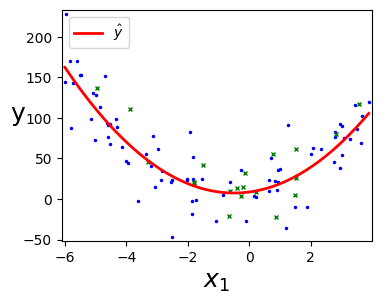

In [24]:
plt.figure(figsize=(4,3))
plot_model(lasso_reg,x1,y)
plt.show()

In [25]:
from sklearn.linear_model import ElasticNet
elastic_reg=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("elastic",ElasticNet(alpha=1,l1_ratio=0.5,random_state=1))
])

In [26]:
elastic_reg.fit(x1_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('elastic', ElasticNet(alpha=1, random_state=1))])

In [27]:
elastic_reg.score(x1_train,y_train),elastic_reg.score(x1_test,y_test)

(0.5863340512948914, 0.5331573407141718)

In [28]:
elastic_reg.predict(x1_test[:3])

array([50.69422872, 58.62751416, 29.73199465])

In [29]:
from sklearn.linear_model import SGDRegressor
elastic_sgd=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("scal",StandardScaler()),
    ("sgd",SGDRegressor(penalty="l2",l1_ratio=0.5,alpha=1,random_state=1))
])
elastic_sgd.fit(x1_train,y_train.ravel())

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()),
                ('sgd', SGDRegressor(alpha=1, l1_ratio=0.5, random_state=1))])

In [30]:
elastic_sgd.score(x1_train,y_train),elastic_sgd.score(x1_test,y_test)

(0.48914255940966433, 0.4132817374249068)

In [31]:
elastic_sgd.predict(x1_test[:3])

array([47.78375855, 58.58856714, 35.37888686])

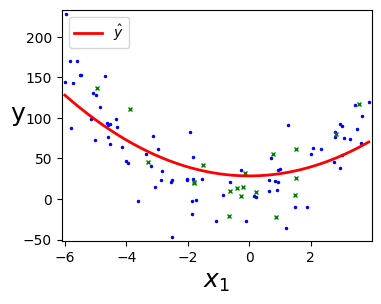

In [32]:
plt.figure(figsize=(4,3))
plot_model(elastic_reg,x1,y)
plt.show()